In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

titanic_df = pd.read_csv("train.csv")

print("Original shape:", titanic_df.shape)
display(titanic_df.head(5))

Original shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


🌟 **Exercise 1: Duplicate Detection and Removal**

In [4]:
#Check the number of rows before removing duplicates
rows_before = len(titanic_df)       

print("Rows before removing duplicates:", rows_before)

Rows before removing duplicates: 891


In [5]:
# Identify duplicate rows 

duplicates = titanic_df[titanic_df.duplicated()]

print(f"Number of duplicate rows: \n{duplicates.sum()}")

Number of duplicate rows: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            0.0
SibSp            0
Parch            0
Ticket           0
Fare           0.0
Cabin            0
Embarked         0
dtype: object


In [6]:
#Remove  the duplicates
titanic_no_dup = titanic_df.drop_duplicates()


In [7]:
#Verify the removal
rows_after = len(titanic_no_dup)

print("Rows after removing duplicates:", rows_after)


Rows after removing duplicates: 891


In [8]:
# Verify that duplicates have been removed

print("Duplicates remaining:", titanic_no_dup.duplicated().sum())

Duplicates remaining: 0


**🌟 Exercise 2: Handling Missing Values**

In [9]:
#Identifying and counting missing values in each column
missing_values = titanic_no_dup.isnull().sum()

missing_values[missing_values > 0]


Age         177
Cabin       687
Embarked      2
dtype: int64

In [10]:
# Remove rows where the embarkation port is missing.
titanic_df = titanic_df.dropna(subset=["Embarked"]).copy()


In [13]:
# Calculate the median of the available ages.
median_age = titanic_df["Age"].median()

In [14]:
# Replace missing ages with that median.
titanic_df["Age"] = titanic_df["Age"].fillna(median_age)

In [15]:
# Replace missing cabin values with a descriptive constant.
titanic_df["Cabin"] = titanic_df["Cabin"].fillna("Unknown")

In [16]:
# Report how many rows were removed.
print("Rows removed:", rows_before - len(titanic_df))


Rows removed: 2


In [17]:
#  Check for any remaining missing values.
print("Missing values after cleaning:")
print(titanic_df.isna().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


**🌟 Exercise 3: Feature Engineering**

In [18]:
# Include the passenger when calculating family size.
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1

titanic_df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [19]:
# Extract the text between the comma and the following period.
titanic_df["Title"] = titanic_df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)

titanic_df["Title"] = titanic_df["Title"].str.strip()

titanic_df["Title"] = titanic_df["Title"].fillna("Unknown")

titanic_df[["Name", "Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [ ]:
titanic_df["Title"].value_counts()

In [ ]:
# Create one numerical indicator column for each title.
titanic_df = pd.get_dummies(titanic_df, columns=["Title"], prefix="Title", dtype=int)

titanic_df.filter(like="Title_").head()

In [ ]:
title_columns = titanic_df.filter(like="Title_").columns.tolist()

titanic_df[["FamilySize"] + title_columns].head()

***🌟 Exercise 4: Outlier Detection and Handling***

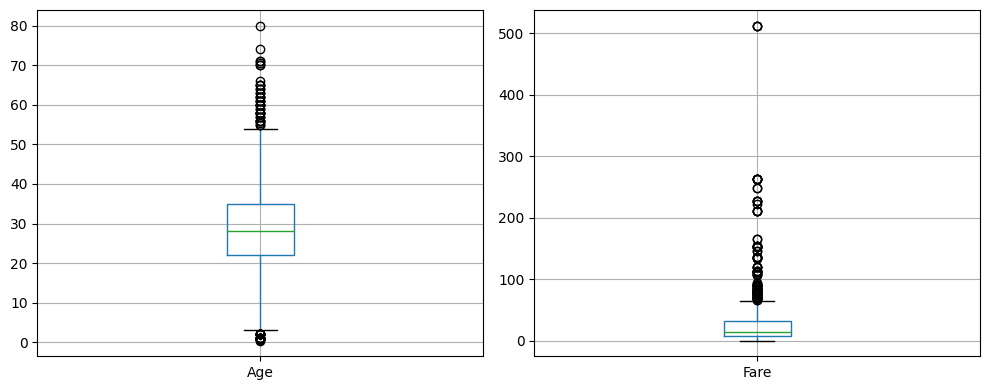

In [23]:
#Visualize potential outliers

before_outliers = titanic_df[["Age", "Fare"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before_outliers.boxplot(column="Age", ax=axes[0])
before_outliers.boxplot(column="Fare", ax=axes[1])

plt.tight_layout()
plt.show()

In [24]:
#Detect outliers using the IQR method

q1 = before_outliers.quantile(0.25)
q3 = before_outliers.quantile(0.75)

iqr = q3 - q1

lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_mask = (before_outliers < lower_bounds) | (before_outliers > upper_bounds)

print(outlier_mask.sum())

Age      65
Fare    114
dtype: int64
